# Statistical Analysis on Flight Delays

## Introduction

Delays are caused by many different factors. What we want to do here is try to find a link between delays and many factors, such as airplane maintenance or weather conditions.

We are going to proceed by steps :
1. Load the datasets and take a look at them to understand the data.
2. Filter flights with the target_flights dataset.
3. Calculate the departure and arrival delays, select flights that have an important delay.
4. Put the weather info into the flight dataframe, to analyse if there is a link between the delay and the weather condition.
5. Insert the maintenance data into the flight dataframe, and analyse if there is also a correlation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Datasets

First, we have to load the datasets we're going to need in this exercise :

In [ ]:
dt_flights = pd.read_csv("data/flights.csv", sep=';')
dt_maintenance = pd.read_csv("data/maintenance.csv", sep=';')
dt_target_flights = pd.read_csv("data/target_flights.csv", sep=';')
dt_weather = pd.read_csv("data/weather.csv", sep=';')

We can take a look at the dataframes to get an idea of how the data is presented.

In [4]:
dt_flights.head()

,flight_id,departure_airport,arrival_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,aircraft_type,status
0,AF123,CDG,JFK,2024-06-10 08:30,2024-06-10 08:50,2024-06-10 11:00,2024-06-10 11:15,A380,delayed
1,BA456,LHR,CDG,2024-06-10 09:00,2024-06-10 09:05,2024-06-10 10:20,2024-06-10 10:18,A320,on-time
2,DL789,JFK,CDG,2024-06-10 07:00,2024-06-10 07:00,2024-06-10 19:30,2024-06-10 19:25,B777,on-time
3,LH321,FRA,CDG,2024-06-10 10:00,2024-06-10 10:50,2024-06-10 11:20,2024-06-10 12:10,A320,delayed
4,EK205,DXB,CDG,2024-06-10 14:30,2024-06-10 14:35,2024-06-10 19:45,2024-06-10 19:40,A380,on-time


In [ ]:
dt_target_flights.head()

,flight_id
0,AF123
1,LH321
2,EK205
3,KL892
4,UA567


In [6]:
#dt_maintenance.head()
#dt_weather.head()

We have to check is there are any missing values in the dt_flights dataframe.

In [7]:
dt_flights.isna().sum()

flight_id              1
departure_airport      1
arrival_airport        1
scheduled_departure    1
actual_departure       3
scheduled_arrival      1
actual_arrival         3
aircraft_type          2
status                 1
dtype: int64

What we can say :
- The missing values in the actual_departure and actual_arrival columns might be because the flight was cancelled : we can keep this row because we might want to know why it was cancelled.
- We will treat the other missing values afterwards.

## 2. Filter the Flights

Now, we have to select only the flights who have their identifier in the scope dataframe.

We will do that using the merge function from the Pandas library, that merges tables the same way SQL does it.

In [ ]:
dt_flights_target = pd.merge(dt_flights, dt_target_flights, how='inner', on='flight_id')

dt_flights_target.head()

,flight_id,departure_airport,arrival_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,aircraft_type,status
0,AF123,CDG,JFK,2024-06-10 08:30,2024-06-10 08:50,2024-06-10 11:00,2024-06-10 11:15,A380,delayed
1,LH321,FRA,CDG,2024-06-10 10:00,2024-06-10 10:50,2024-06-10 11:20,2024-06-10 12:10,A320,delayed
2,EK205,DXB,CDG,2024-06-10 14:30,2024-06-10 14:35,2024-06-10 19:45,2024-06-10 19:40,A380,on-time
3,KL892,AMS,JFK,2024-06-10 11:15,2024-06-10 11:45,2024-06-10 14:20,2024-06-10 14:55,B787,delayed
4,UA567,ORD,LHR,2024-06-10 16:00,2024-06-10 16:00,2024-06-10 06:30,2024-06-10 06:25,B777,on-time


In [ ]:
dt_flights_target.isna().sum()

flight_id              0
departure_airport      1
arrival_airport        1
scheduled_departure    1
actual_departure       3
scheduled_arrival      1
actual_arrival         3
aircraft_type          2
status                 1
dtype: int64

We get the modified dataframe with 81 rows (3 rows were left out from the original dataset).

## 3. Get the Departure and Arrival Delays

We need to change the type of the columns scheduled_departure, actual_departure, scheduled_arrival and actual_arrival to make the computations easier.

The Pandas library handles very well time-based data, we can change the type of these columns to the datatime64 datatype.

While trying to convert the columns to datetime, an error made us see that some observations had a wrong format (February 30th for example).

We have two choices :
- Correct the error if it's possible.
- Delete the rows

In [ ]:
dt_flights_target.loc[[8, 20, 60, 61, 63, 67, 70, 71, 72, 73]] # some rows have a wrong date format

,flight_id,departure_airport,arrival_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,aircraft_type,status
8,TK056,IST,JFK,2024-06-10 13:45,INVALID_TIME,2024-06-10 18:30,2024-06-10 19:00,A330,delayed
20,MK567,CDG,JFK,2024-02-30 10:00,2024-02-30 10:30,2024-02-30 13:30,2024-02-30 14:00,A340,delayed
60,XY999,JFK,CDG,25-12-2023 14:00,25-12-2023 14:30,25-12-2023 03:30,25-12-2023 03:45,NaN,cancelled
61,AB001,CDG,LHR,2024-06-10 25:30,2024-06-10 25:45,2024-06-10 27:15,2024-06-10 27:30,A320,delayed
63,EF003,FRA,CDG,2024-13-45 10:00,2024-13-45 10:30,2024-13-45 11:30,2024-13-45 12:00,A319,delayed
67,MN007,CDG,JFK,NaN,NaN,NaN,NaN,A380,unknown
70,ST010,AMS,CDG,2024-06-10 13:45,NaN,2024-06-10 15:30,NaN,A319,delayed
71,UV011,BRU,LHR,2024-06-10 08:30,NaN,2024-06-10 09:45,NaN,B737,cancelled
72,WX012,ZUR,CDG,2024-06-10 14:15,-,2024-06-10 16:00,-,A220,cancelled
73,YZ013,VIE,JFK,2024-06-10 10:30,TBD,2024-06-10 14:45,TBD,A330,pending


Here, we're just going to delete the rows before changing the type : we can see that most of them weren't interesting anyway (no info on the actual departure time).

Note : There are two rows I could have kept as there is no departure time, but because the flight was cancelled (rows 71/72).
In the end, I chose to pass the parameter errors with value 'coerce' that forces values with wrong format to be given the value NaT, so that I can keep the cancelled flights' info.

In [ ]:
dt_flights_target.drop([8, 20, 60, 61, 63, 67, 70, 73], axis=0, inplace=True)
# drop the rows that don't have the right date format
dt_flights_target.reset_index(drop=True, inplace=True)
# reset the indexes (optional : just to have a clean table)

In [ ]:
dt_flights_target['scheduled_departure'] = pd.to_datetime(dt_flights_target['scheduled_departure'], format='%Y-%m-%d %H:%M', yearfirst=True, errors='coerce')
dt_flights_target['actual_departure'] = pd.to_datetime(dt_flights_target['actual_departure'], format='%Y-%m-%d %H:%M', yearfirst=True, errors='coerce')
dt_flights_target['scheduled_arrival'] = pd.to_datetime(dt_flights_target['scheduled_arrival'], format='%Y-%m-%d %H:%M', yearfirst=True, errors='coerce')
dt_flights_target['actual_arrival'] = pd.to_datetime(dt_flights_target['actual_arrival'], format='%Y-%m-%d %H:%M', yearfirst=True, errors='coerce')

Now that the type of these rows is datetime64, we can perform operations on these columns. We are going to compute the delays experienced at departure and arrival.

In [ ]:
dt_flights_target.insert(5, 'delay_departure', (dt_flights_target['actual_departure'] - dt_flights_target['scheduled_departure']))
dt_flights_target.insert(8, 'delay_arrival', (dt_flights_target['actual_arrival'] - dt_flights_target['scheduled_arrival']))

dt_flights_target.head()
#dt_flights_target['delay_arrival'] - dt_flights_target['delay_departure']

,flight_id,departure_airport,arrival_airport,scheduled_departure,actual_departure,delay_departure,scheduled_arrival,actual_arrival,delay_arrival,aircraft_type,status
0,AF123,CDG,JFK,2024-06-10 08:30:00,2024-06-10 08:50:00,0 days 00:20:00,2024-06-10 11:00:00,2024-06-10 11:15:00,0 days 00:15:00,A380,delayed
1,LH321,FRA,CDG,2024-06-10 10:00:00,2024-06-10 10:50:00,0 days 00:50:00,2024-06-10 11:20:00,2024-06-10 12:10:00,0 days 00:50:00,A320,delayed
2,EK205,DXB,CDG,2024-06-10 14:30:00,2024-06-10 14:35:00,0 days 00:05:00,2024-06-10 19:45:00,2024-06-10 19:40:00,-1 days +23:55:00,A380,on-time
3,KL892,AMS,JFK,2024-06-10 11:15:00,2024-06-10 11:45:00,0 days 00:30:00,2024-06-10 14:20:00,2024-06-10 14:55:00,0 days 00:35:00,B787,delayed
4,UA567,ORD,LHR,2024-06-10 16:00:00,2024-06-10 16:00:00,0 days 00:00:00,2024-06-10 06:30:00,2024-06-10 06:25:00,-1 days +23:55:00,B777,on-time


We can now read the table this way :
- The XZ123 flight from CDG to JFK took off 20 minutes late, arrived 15 minutes late in New York City : the status column tells us the flight was delayed.
- The EK205 flight arrived 5 minutes early at the airport.

Note : The line I didn't run is just here to check if the airplane gets to reduce the initial delay during the flight. We can observe that on average, the delay stays the same.

One thing is yet to be modified : the status column. Some values are not in the right format and we might want to encode them anyway to use it later for regression.

Let's give them the following values :
- 0 if the flight is on-time for departure
- 1 if it's delayed
- 2 if it's cancelled

In [ ]:
dt_flights_target['status'].unique()

array(['delayed', 'on-time', nan, 'cancelled', '0n-t1me', 'ON_TIME',
       'Delayed', 'CANCELLED', 'active', 'boarding', 'taxi-out'],
      dtype=object)

In [ ]:
dt_flights_target['status'] = dt_flights_target['status'].replace(['on-time','0n-t1me', 'ON_TIME', np.nan,'active', 'boarding', 'taxi-out', 'delayed', 'Delayed', 'cancelled', 'CANCELLED'], [0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2])

/tmp/ipykernel_21023/3416348524.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt_flights_scope['status'] = dt_flights_scope['status'].replace(['on-time','0n-t1me', 'ON_TIME', np.nan,'active', 'boarding', 'taxi-out', 'delayed', 'Delayed', 'cancelled', 'CANCELLED'], [0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2])


In [ ]:
dt_flights_target.dtypes

flight_id                       object
departure_airport               object
arrival_airport                 object
scheduled_departure     datetime64[ns]
actual_departure        datetime64[ns]
delay_departure        timedelta64[ns]
scheduled_arrival       datetime64[ns]
actual_arrival          datetime64[ns]
delay_arrival          timedelta64[ns]
aircraft_type                   object
status                           int64
dtype: object

Something weird happens : when we display the cancelled flights (there are only three in dt_flights_target), we can see that one wasn't cancelled and was in fact on-time. When looking at the entire table we can see that it's not the only wrong value for status, so we are going to make it ourselves.

In [ ]:
dt_flights_target[dt_flights_target['status']==2]

,flight_id,departure_airport,arrival_airport,scheduled_departure,actual_departure,delay_departure,scheduled_arrival,actual_arrival,delay_arrival,aircraft_type,status
64,UV011,BRU,LHR,2024-06-10 08:30:00,NaT,NaT,2024-06-10 09:45:00,NaT,NaT,B737,2
65,WX012,ZUR,CDG,2024-06-10 14:15:00,NaT,NaT,2024-06-10 16:00:00,NaT,NaT,A220,2
69,DD017,OSL,JFK,2024-06-10 18:00:00,2024-06-10 18:00:00,0 days,2024-06-10 21:15:00,2024-06-10 21:15:00,0 days,B787,2


In [ ]:
tmp = dt_flights_target.iloc[[64,65]] # these columns are flights that were cancelled

In [ ]:
dt_flights_target['status'] = pd.Series(dt_flights_target['actual_arrival'] - dt_flights_target['scheduled_arrival'] > pd.Timedelta(minutes = 0)) # True if there is a delay; else False
dt_flights_target['status'] = dt_flights_target['status'].astype('int') # conversion to int64

In [ ]:
dt_flights_target.iloc[[64,65]] = tmp # we give them back the cancelled status value (2)

We now want to select only the flights that have a significant delay (> 30 minutes). As our goal is to analyse the causes of the delays at departure, we are going to select flights whose departure delay is greater than 30 minutes.

In [ ]:
delay = pd.Timedelta(minutes=30)
dt_flights_target_delayed = dt_flights_target[dt_flights_target['delay_departure']>=delay]
# we add the two cancelled flights (the condition is not met although the were cancelled because they are NaT)
dt_flights_target_delayed = pd.concat([dt_flights_target_delayed, tmp])

## 4. Insert Weather Data and look for a Correlation with the Delay

As we did previously, we can merge the two dataframes into one with the merge function. We need to change the type of the datetime column in the weather dataframe to datetime64 before merging the two tables as we're going to join them based on the airport and the time. Indeed we want to have the weather conditions at the time of the scheduled departure.

In [22]:
dt_weather['datetime'] = pd.to_datetime(dt_weather['datetime'], format='%Y-%m-%d %H:%M', yearfirst=True) # direct : no error in formating

In [ ]:
dt_flights_delayed_weather = dt_flights_target_delayed.merge(dt_weather, how='inner',
                               left_on=['departure_airport', 'scheduled_departure'],
                               right_on=['airport_code', 'datetime'])

print(f'number of flights in the table : {dt_flights_delayed_weather.shape[0]}')

number of flights in the table : 9


We can plot some graphs to see how the weather data at departure is distributed for delayed flights :

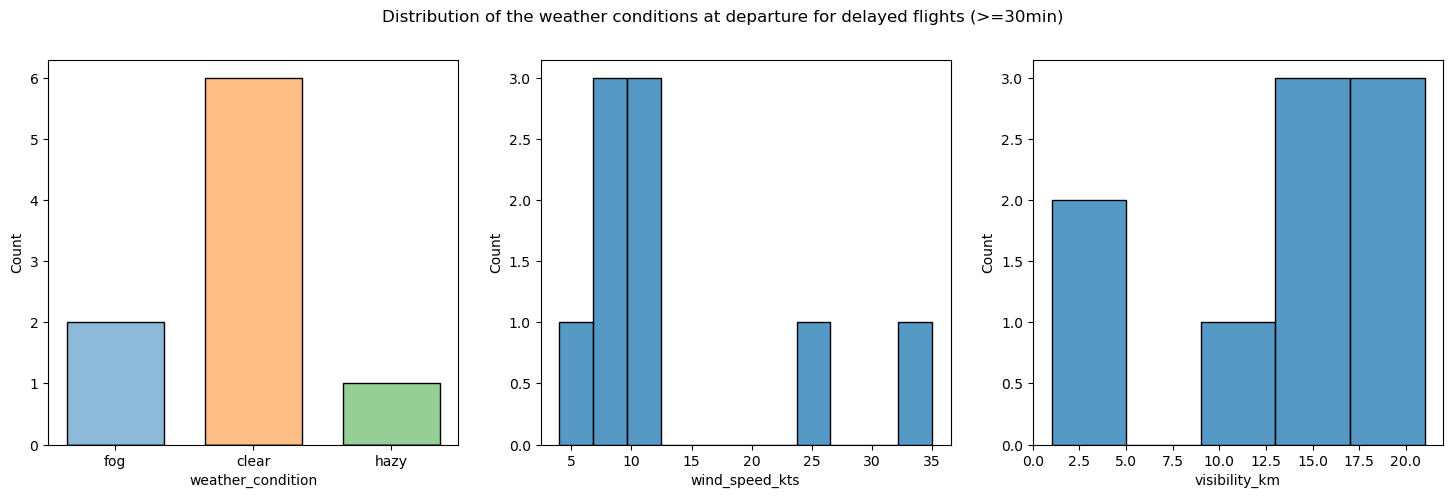

In [24]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 5))

sns.histplot(data=dt_flights_delayed_weather, x='weather_condition',
             discrete=True, shrink=0.7, hue='weather_condition',
             legend=False, ax=axes[0])
sns.histplot(data=dt_flights_delayed_weather, x='wind_speed_kts',
             ax=axes[1])
sns.histplot(data=dt_flights_delayed_weather, x='visibility_km',
             ax=axes[2])

fig.suptitle('Distribution of the weather conditions at departure for delayed flights (>=30min)')
plt.show()

There is few data on delayed flights during harsh weather conditions : there is not that much data to analyse with this specific table.

One thing we could do to have a better idea on how weather conditions impact the departure is to merge the weather conditions table with the flights table we had before keeping only the flights that had a major delay. That way we could fit a model (a linear regression for example) that predicts the status value from the weather conditions, and look for the coefficients of the regression.

In [ ]:
dt_flights_weather = dt_flights_target.merge(dt_weather, how='inner',
                               left_on=['departure_airport', 'scheduled_departure'],
                               right_on=['airport_code', 'datetime'])

In [26]:
dt_flights_weather[dt_flights_weather['weather_condition'] == 'rain'] # just one delayed flight under rainy conditions

,flight_id,departure_airport,arrival_airport,scheduled_departure,actual_departure,delay_departure,scheduled_arrival,actual_arrival,delay_arrival,aircraft_type,status,airport_code,datetime,wind_speed_kts,visibility_km,weather_condition
14,CD002,LHR,JFK,2024-06-10 08:00:00,2024-06-10 08:15:00,0 days 00:15:00,2024-06-09 14:30:00,2024-06-09 14:45:00,0 days 00:15:00,B777,1,LHR,2024-06-10 08:00:00,15,8,rain
15,AA014,CPH,CDG,2024-06-10 15:00:00,2024-06-10 15:00:00,0 days 00:00:00,2024-06-10 17:30:00,2024-06-10 17:30:00,0 days 00:00:00,A320,0,CPH,2024-06-10 15:00:00,17,9,rain


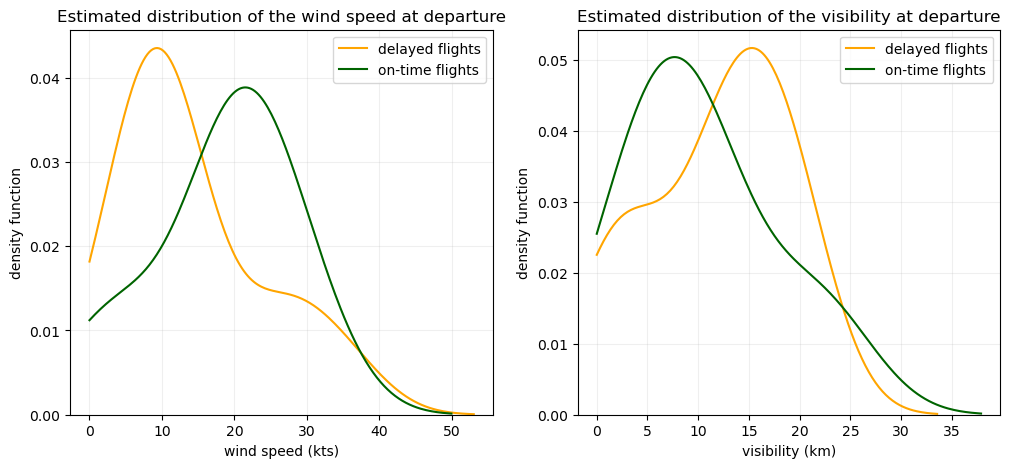

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

# first graph : wind_speed
sns.kdeplot(dt_flights_weather[dt_flights_weather['delay_departure']>pd.Timedelta(minutes=0)]['wind_speed_kts'], # in the delay_departure column : delay = 0 min
            clip=(0, None),
            ax=axes[0], color='orange', label='delayed flights')
sns.kdeplot(dt_flights_weather[dt_flights_weather['delay_departure']==pd.Timedelta(minutes=0)]['wind_speed_kts'], # > 0 min
            clip=(0,None),
            ax=axes[0], color='darkgreen', label='on-time flights')

# second graph : visibility
sns.kdeplot(dt_flights_weather[dt_flights_weather['delay_departure']>pd.Timedelta(minutes=0)]['visibility_km'],
            clip=(0, None),
            ax=axes[1], color='orange', label='delayed flights')
sns.kdeplot(dt_flights_weather[dt_flights_weather['delay_departure']==pd.Timedelta(minutes=0)]['visibility_km'],
            clip=(0,None),
            ax=axes[1], color='darkgreen', label='on-time flights')

for ax in axes:
  ax.set_ylabel('density function')
  ax.grid(alpha=0.2)
  ax.legend()

axes[0].set_xlabel('wind speed (kts)')
axes[1].set_xlabel('visibility (km)')

axes[0].set_title('Estimated distribution of the wind speed at departure')
axes[1].set_title('Estimated distribution of the visibility at departure')

plt.show()

These graphs show the estimation of the probability density function of the wind speed and the visibility for on-time and delayed flights : what we wanted to see here is if these two parameters could be a source of delay.

For the two graphs the functions look very similar so the correlation is not obvious if there is one : we would have to dig deeper, do some statistical tests (for example the two-sample Student t-test) or fit a linear model and check the coefficients.

Let's first do the Student t-test for the two factors : the wind speed and the visibility.
We assume that the observations are independant (weather conditions at two different airports are independant) and the standard deviations of the two samples are equal. The alternative hypothesis $H_1$ is : "The mean of the two samples is not equal". This means that if we reject the null hypothesis, we assume that the factor impacts the departure time.

In [28]:
from scipy.stats import ttest_ind
# wind speed
sample_ontime = dt_flights_weather[dt_flights_weather['status']==0]['wind_speed_kts']
sample_delayed = dt_flights_weather[dt_flights_weather['status']>0]['wind_speed_kts']
print(f'p-value = {ttest_ind(sample_ontime, sample_delayed).pvalue}')

p-value = 0.15606608748011233


The p-value is equal $0.156$. We can't reject the null hypothesis. If we were to reject this hypothesis and say wind speed has an effect on delays, we would have a $15\%$ chance to be wrong.

We can do the same test for the effect of visibility on delays.

In [29]:
sample_ontime = dt_flights_weather[dt_flights_weather['status']==0]['visibility_km']
sample_delayed = dt_flights_weather[dt_flights_weather['status']>0]['visibility_km']
print(f'p-value = {ttest_ind(sample_ontime, sample_delayed).pvalue}')

p-value = 0.3305831566417644


Again, the p-value of the test indicates that it is very unlikely that low visibility is linked with delays at departure. However we can still search for correlation using other methods.

We cannot do this t-test for the weather condtions column because it is a categorical column, so we might consider fitting a classification model to our data and see how well it predicts new observations.

We will do so with a logistic regresion. We decided to keep only two factors for the observation vector (wind_conditions and wind speed) as visibility seemed to have no effect on delays.

We just have to make one adjustment before, encode the weather_condition column :
- 0 for the 'clear' value
- 1 for 'hazy' and 'fog'
- 2 for 'rain' and 'storm'

different values :  ['fog' 'clear' 'storm' 'hazy' 'rain']


/tmp/ipykernel_21023/2958855322.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dt_flights_weather['weather_condition'] = dt_flights_weather['weather_condition'].replace(['clear', 'hazy', 'fog', 'rain', 'storm'], [0, 1, 1, 2, 2])


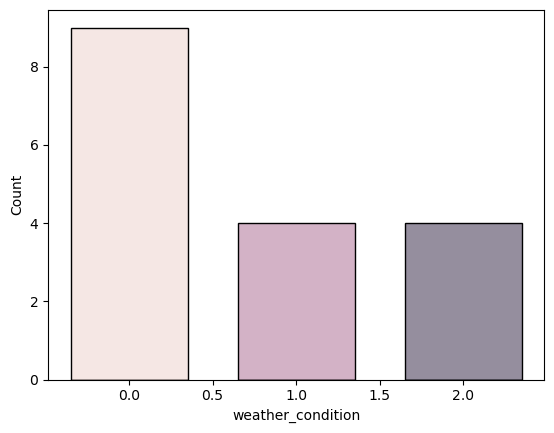

In [30]:
print('different values : ', dt_flights_weather['weather_condition'].unique())

dt_flights_weather['weather_condition'] = dt_flights_weather['weather_condition'].replace(['clear', 'hazy', 'fog', 'rain', 'storm'], [0, 1, 1, 2, 2])

sns.histplot(data=dt_flights_weather, x='weather_condition',
             discrete=True, shrink=0.7, hue='weather_condition',
             legend=False)
plt.show()

The repartition is somehow balanced, we can now proceed to the estimation of the model precision.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = dt_flights_weather[['wind_speed_kts', 'weather_condition']]
y = dt_flights_weather['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
clf = LogisticRegression().fit(X_train, y_train)
print(f'Percentage of good prediction : {clf.score(X_test, y_test)}')

Percentage of good prediction : 0.8


The score of the model is actually not bad since the train dataset is made of only 12 observations. We can't draw any conclusions as the model score has a great variance. Nevertheless we can look at the coefficients of the regression to have an idea of the contribution of each variable :

In [32]:
np.exp(clf.coef_) # odd-ratios

array([[0.97962101, 0.53716559]])

This is how we interpret it : for each increment of the 'weather_condition' value by 1, it is $0.71\times$ more likely to predict 1 (delay).

In our case, it means that as the weather worsens, the probability of delay decreases.

### Conclusion:
Our findings are counterintuitive : we find that difficult weather conditions don't affect the departure time, and might decrease the probability of delay. That's very unlikely, in real life these factors make it difficult for pilots to take off and it definitely impacts punctuality.

My personal opinion is that we have an unbalanced dataset with few observations. Moreover in our set most of the flights that took place under bad weather departed on time and it might just be a coincidence that flaw the analysis.

## 5. Insert maintenance data

Let's now insert the maintenance dataframe into the dt_flights_target dataframe.

We have to take into account that the aircraft ID is not specified in the dt_flights table : there is no way to be sure that the aircraft we are going to attach to each flight is the one used in reality (there are many different A320 airplanes in  both the flight and maintenance tables).

In [33]:
dt_maintenance.dropna(axis=0, inplace=True) # we can delete rows with missing values : they are useless (no info about the maintenance type)
dt_maintenance['last_maintenance_date'] = pd.to_datetime(dt_maintenance['last_maintenance_date'], format='%Y-%m-%d')

In [ ]:
print(dt_flights_target['aircraft_type'].unique()) # the values 'UNKNOWN' and nan are not important, they will be discarded when merged
print(dt_maintenance['aircraft_type'].unique())

['A380' 'A320' 'B787' 'B777' 'A330' 'A350' 'A321' 'B737' 'B757' 'A220'
 'A319' 'UNKNOWN' nan]
['A380' 'A320' 'B777' 'B787' 'A330' 'A350' 'A321' 'B737' 'B757' 'A220'
 'A319']


### Conclusion:

Without any information on aircraft ID, we cannot keep analyzing maintenance data. It is impossible to match maintenance status with the flight table. This issue prevents us from analyzing the possible link between aircraft maintenance and flight delays.